**Table of contents**<a id='toc0_'></a>    
- [Solving the permanent income model with VFI](#toc1_)    
  - [The model](#toc1_1_)    
  - [The closed-form solution](#toc1_2_)    
  - [Finite horizon: backward induction](#toc1_3_)    
  - [Does it work?](#toc1_4_)    
    - [Accuracy and the number of grid points](#toc1_4_1_)    
  - [Infinite horizon](#toc1_5_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

In [1]:
import time

import numpy as np
import numba as nb
import matplotlib.pyplot as plt

from consav.grids import equilogspace
from consav.linear_interp import interp_1d, interp_1d_vec
from consav.golden_section_search import optimizer

# <a id='toc1_'></a>[Solving the permanent income model with VFI](#toc0_)

This notebook solves the deterministic consumption-saving problem with value function iteration (VFI), and checks the answer against the closed-form solution.
This is the only model in the course where we know the exact answer.
It is therefore the one chance we get to verify that the numerical machinery is right, before we point it at problems where we cannot check.

Two parts:
1. **Finite horizon**: solve backwards from the last period of life (*backward induction*).
2. **Infinite horizon**: keep stepping backwards until the value function stops changing.

From this notebook on we use the compiled tools from `consav` (`equilogspace`, `interp_1d`, `optimizer`) instead of the plain `numpy` versions we built in the previous notebook, and we `numba`-compile the solver itself, written as simple loops over the asset grid.

## <a id='toc1_1_'></a>[The model](#toc0_)

The household solves

$$
\begin{aligned}
v_0 &= \max_{\{c_t\}_{t=0}^{T-1}} \sum_{t=0}^{T-1}\beta^t \frac{c_t^{1-\sigma}}{1-\sigma} \\
&\text{s.t.} \\
a_t &= (1+r)a_{t-1} + y_t - c_t \\
a_t &\geq \underline{a}, \quad a_{T-1} = 0
\end{aligned}
$$

Income $y_t$ is a *known sequence*, so there is no risk and the only state variable is $a_{t-1}$.

As in the previous notebook, we hold the parameters in a class.
We take a household with a falling income profile, saving for retirement.

In [2]:
class Parameters:
    def __init__(self):
        # preferences
        self.beta = 0.99
        self.sigma = 2.0

        # income and interest rate
        self.r = 0.02
        self.y = np.array([1.5,1.0,0.5])

        # grids
        self.T = 3
        self.Na = 200
        self.a_min = 0.0
        self.a_max = 5.0
        self.a_grid = equilogspace(self.a_min,self.a_max,self.Na)

par = Parameters()

## <a id='toc1_2_'></a>[The closed-form solution](#toc0_)

Before solving anything numerically, let us write down the answer.

The Euler-equation gives $c_t = (\beta R)^{t/\sigma}c_0$ with $R \equiv 1+r$.
Substituting this into the intertemporal budget constraint $\sum_t R^{-t}c_t = s_0 + h_0$ and solving for $c_0$,

$$
c_0^{\ast} = \frac{1-\kappa}{1-\kappa^T}(s_0+h_0),
\qquad \kappa \equiv \frac{(\beta R)^{1/\sigma}}{R},
\qquad s_0 \equiv Ra_{-1},
\qquad h_0 \equiv \sum_{t=0}^{T-1}R^{-t}y_t
$$

Note that this holds *only* if the borrowing constraint never binds.
We will check that it does not.

In [3]:
R = 1+par.r

kappa = (par.beta*R)**(1/par.sigma)/R
MPC = (1-kappa)/(1-kappa**par.T) # the marginal propensity to consume out of total resources
h0 = np.sum(par.y/R**np.arange(par.T)) # human capital, the present value of the income path

c0_closed = MPC*(R*par.a_grid + h0)

print(f'{kappa = :.6f}')
print(f'{MPC = :.6f}')
print(f'{h0 = :.6f}')

kappa = 0.985184
MPC = 0.338321
h0 = 2.960977


## <a id='toc1_3_'></a>[Finite horizon: backward induction](#toc0_)

Our goal is the policy function $c_t(a_{t-1})$ for each point on the grid `a_grid` and each period $t$.
We write the problem recursively,

$$
v_t(a_{t-1}) = \max_{c_t} \frac{c_t^{1-\sigma}}{1-\sigma} + \beta v_{t+1}(a_t),
\qquad a_t = (1+r)a_{t-1}+y_t-c_t \geq \underline{a}
$$

and solve it backwards from the last period.

The state is *wealth* $a_{t-1}$, not cash-on-hand $(1+r)a_{t-1}+y_t$.
Both carry the same information here, but with wealth as the state the grid means the same thing in every period, and everything that varies over time sits in $v_t$.
This is what lets us add a stochastic income state $z_t$ later without touching the asset grid.

We start at the end.
In the last period there is no tomorrow, so the household consumes everything it has, $c_{T-1} = (1+r)a_{T-2}+y_{T-1}$.

In [4]:
c = np.zeros((par.T,par.Na))
a = np.zeros((par.T,par.Na))
v = np.zeros((par.T,par.Na))

t = par.T-1

c[t] = (1+par.r)*par.a_grid + par.y[t] # consume everything
a[t] = 0.0
v[t] = c[t]**(1-par.sigma)/(1-par.sigma)

Now step back one period.
Take a *single* point on the asset grid, say `i_a_lag = 100`, and ask what the household would get from each possible choice of $c_t$.

The choice has to leave the household with at least $\underline{a}$, so $c_t$ can be anything between $0$ and the cash-on-hand $m = (1+r)a_{t-1}+y_t$ minus $\underline{a}$.

In [5]:
t = par.T-2
i_a_lag = 100

a_lag = par.a_grid[i_a_lag]
m = (1+par.r)*a_lag + par.y[t] # cash-on-hand
c_max = m - par.a_min

print(f'wealth entering the period: {a_lag:.4f}')
print(f'income this period:         {par.y[t]:.4f}')
print(f'largest feasible c:         {c_max:.4f}')

wealth entering the period: 0.9044
income this period:         1.0000
largest feasible c:         1.9225


Note that $v_{t+1}$ is only known *on the grid*, so to evaluate the continuation value at $a_t = m-c_t$ we have to interpolate.
This is the job of `interp_1d` from `consav`, the compiled version of the linear interpolation we built in the previous notebook (`interp_1d_vec` is the same thing for a whole array of points, writing the result into the array we pass last).

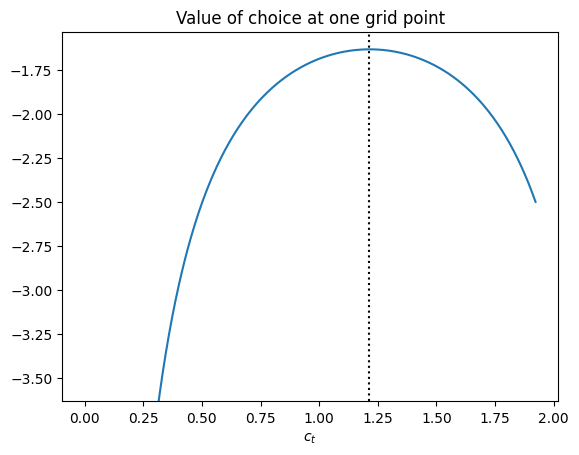

best c on this trial grid: 1.212406


In [6]:
c_trials = np.linspace(1e-8,c_max,1_000)

utility = c_trials**(1-par.sigma)/(1-par.sigma)
continuation = np.empty(c_trials.size)
interp_1d_vec(par.a_grid,v[t+1],m-c_trials,continuation)
value = utility + par.beta*continuation

plt.plot(c_trials,value)
plt.axvline(c_trials[np.argmax(value)],linestyle=':',color='black')
plt.ylim(np.max(value)-2,np.max(value)+0.1)
plt.title('Value of choice at one grid point')
plt.xlabel('$c_t$')
plt.show()

print(f'best c on this trial grid: {c_trials[np.argmax(value)]:.6f}')

The function is concave and has an interior maximum.
Trying 1,000 values is a waste: golden section search finds the same point in a fraction of the evaluations, and to much higher precision.

Let us write the objective as a function so we can hand it to `optimizer` from `consav`.
Two things about it.
It is `numba`-compiled with `@nb.njit`, so it can be called from inside a compiled solver later.
And `optimizer` *minimizes*, so it returns the *negative* of the value.

In [7]:
@nb.njit
def value_of_choice(c,m,beta,sigma,a_grid,v_plus):
    """ negative of the value of consuming c out of cash-on-hand m """

    # a. end-of-period assets implied by the choice
    a = m - c

    # b. utility today plus discounted continuation value
    utility = c**(1-sigma)/(1-sigma)
    continuation = interp_1d(a_grid,v_plus,a)

    return -(utility + beta*continuation)

In [8]:
c_star = optimizer(value_of_choice,1e-8,c_max,args=(m,par.beta,par.sigma,par.a_grid,v[t+1]),tol=1e-10)

print(f'grid search:    {c_trials[np.argmax(value)]:.8f}   (1,000 evaluations)')
print(f'golden section: {c_star:.8f}   (~50 evaluations)')
print(f'spacing of the trial grid: {c_trials[1]-c_trials[0]:.8f}')

grid search:    1.21240632   (1,000 evaluations)
golden section: 1.21171452   (~50 evaluations)
spacing of the trial grid: 0.00192445


The two agree to within the spacing of the trial grid, which is all we can ask of the grid search.
Golden section is the accurate one here: it keeps shrinking the bracket, so its error keeps falling, while the grid search can never do better than the distance between two trial points.

So far we have solved *one* grid point.
We now put everything in one function and loop over the whole grid, backwards over time.

Algorithm:
Set $v_T(\cdot)=0$. Then for $t=T-1,T-2,\dots,0$ and each grid point $a_{t-1}$:
1. If $t=T-1$, consume everything: $c_t = m = (1+r)a_{t-1}+y_t$
2. Otherwise maximize $u(c_t)+\beta \breve{v}_{t+1}(m-c_t)$ over $c_t\in[0,m-\underline{a}]$ with golden section search
3. Store $a_t = m-c_t$ and the value attained

The whole function is `numba`-compiled, so the plain Python loop over grid points costs nothing.
The outputs are written *into* the arrays `c`, `a` and `v` that we pass in, rather than returned; this is the convention `GEModelTools` uses later in the course.

In [9]:
@nb.njit
def solve_backwards(beta,sigma,r,a_min,y,a_grid,c,a,v):
    """ solve the finite-horizon problem backwards from the last period """

    T,Na = c.shape

    for t in range(T-1,-1,-1):
        for i_a_lag in range(Na):

            # i. cash-on-hand and maximum consumption
            m = (1+r)*a_grid[i_a_lag] + y[t]
            c_max = m - a_min

            # ii. consume everything in the last period, otherwise optimize
            if t == T-1:
                c[t,i_a_lag] = m
            else:
                c[t,i_a_lag] = optimizer(value_of_choice,1e-8,c_max,
                    args=(m,beta,sigma,a_grid,v[t+1]),tol=1e-10)

            # iii. save and store the value attained
            a[t,i_a_lag] = m - c[t,i_a_lag]
            v[t,i_a_lag] = c[t,i_a_lag]**(1-sigma)/(1-sigma)
            if t < T-1:
                v[t,i_a_lag] += beta*interp_1d(a_grid,v[t+1],a[t,i_a_lag])

In [10]:
c = np.zeros((par.T,par.Na))
a = np.zeros((par.T,par.Na))
v = np.zeros((par.T,par.Na))

t0 = time.time()
solve_backwards(par.beta,par.sigma,par.r,par.a_min,par.y,par.a_grid,c,a,v)
print(f'solved in {time.time()-t0:.2f} seconds (nearly all of it numba compilation)')

assert np.min(a[:par.T-1]) > 1e-6 # check that the borrowing constraint never binds
print('the borrowing constraint is slack everywhere, so the closed form applies')

solved in 0.08 seconds (nearly all of it numba compilation)
the borrowing constraint is slack everywhere, so the closed form applies


## <a id='toc1_4_'></a>[Does it work?](#toc0_)

Now compare the numerical solution with the closed form.

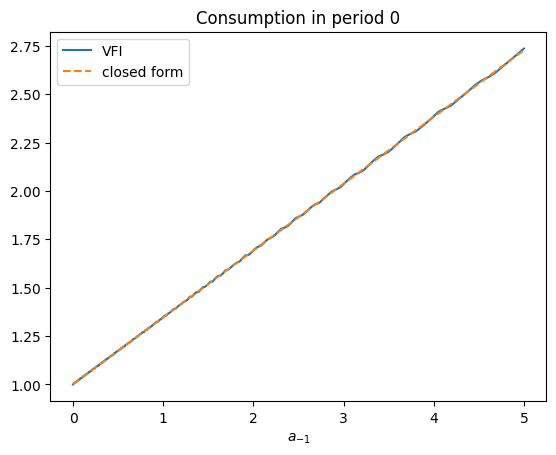

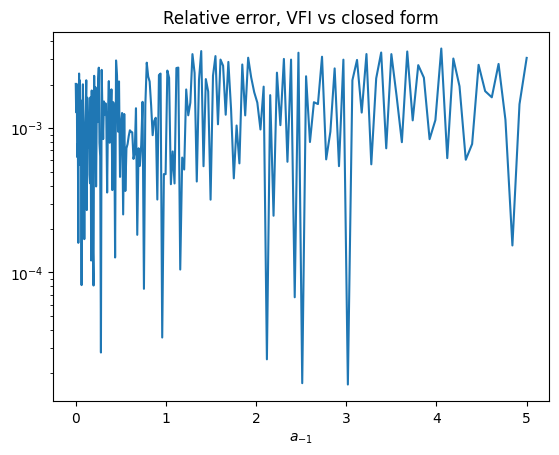

maximum relative error: 3.55e-03


In [11]:
plt.plot(par.a_grid,c[0],label='VFI')
plt.plot(par.a_grid,c0_closed,linestyle='--',label='closed form')
plt.title('Consumption in period 0')
plt.xlabel('$a_{-1}$')
plt.legend()
plt.savefig('figs/pih_vfi_vs_closed.pdf')
plt.show()

plt.plot(par.a_grid,np.abs(c[0]/c0_closed-1))
plt.yscale('log')
plt.title('Relative error, VFI vs closed form')
plt.xlabel('$a_{-1}$')
plt.savefig('figs/pih_vfi_error.pdf')
plt.show()

print(f'maximum relative error: {np.max(np.abs(c[0]/c0_closed-1)):.2e}')

### <a id='toc1_4_1_'></a>[Accuracy and the number of grid points](#toc0_)

How does the error depend on the grid?
Solve the same problem on finer and finer grids and record the maximum relative error.

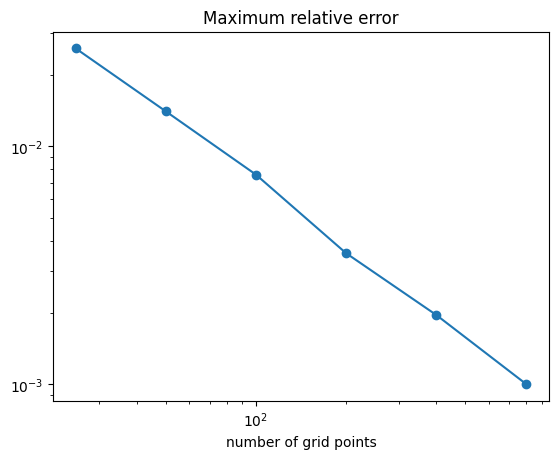

In [12]:
Na_list = np.array([25,50,100,200,400,800])
max_errors = np.empty(Na_list.size)

for i,Na in enumerate(Na_list):

    # a. solve on a grid with Na points
    a_grid = equilogspace(par.a_min,par.a_max,Na)
    c_Na = np.zeros((par.T,Na))
    solve_backwards(par.beta,par.sigma,par.r,par.a_min,par.y,a_grid,
        c_Na,np.zeros((par.T,Na)),np.zeros((par.T,Na)))

    # b. compare with the closed form
    max_errors[i] = np.max(np.abs(c_Na[0]/(MPC*(R*a_grid+h0))-1))

plt.plot(Na_list,max_errors,'-o')
plt.xscale('log')
plt.yscale('log')
plt.title('Maximum relative error')
plt.xlabel('number of grid points')
plt.savefig('figs/pih_vfi_convergence.pdf')
plt.show()

Doubling the grid roughly halves the error.
The bottleneck is interpolating $v_{t+1}$, which is strongly curved: linear interpolation of a curved function makes an error of the order of the grid spacing.
Three more digits of accuracy would need a grid a thousand times finer.
The endogenous grid method of notebook 04 escapes this by interpolating the *policy* function, which is nearly linear, instead of the value function.

## <a id='toc1_5_'></a>[Infinite horizon](#toc0_)

Now let $T \rightarrow \infty$, with a constant income $y_t = 1$.
No period is special any more, so the value function loses its time subscript: the problem is *stationary*,

$$
v(a_{-1}) = \max_{c} \frac{c^{1-\sigma}}{1-\sigma} + \beta v(a),
\qquad a = (1+r)a_{-1}+y-c \geq \underline{a}
$$

The contraction mapping theorem says that iterating the backward step from *any* terminal guess converges to this fixed point.
So the algorithm barely changes: instead of stopping at $t=0$, we keep stepping backwards until $v$ stops moving.
Backward induction and value function *iteration* are the same thing; only the stopping rule differs.

One catch: whether *wealth* settles down depends on $\beta R$.
1. $\beta R > 1$, as in part 1: the household wants consumption *growing* at rate $(\beta R)^{1/\sigma}$, so it saves at every wealth level, accumulates without bound, and walks off the top of any finite grid.
2. $\beta R < 1$: the household runs its wealth down until the borrowing constraint binds, and the closed form no longer applies.
3. $\beta R = 1$: the household wants *constant* consumption, and keeps its wealth exactly constant, $a_t = a_{t-1}$.

We therefore set $\beta = 1/(1+r)$, the permanent income hypothesis proper.
Letting $T\rightarrow\infty$ in the finite-horizon formula gives $c^{\ast}(a_{-1}) = (1-\kappa)(Ra_{-1} + \frac{R}{r}y)$, and with $\kappa = 1/R$ this collapses to the *annuity rule*

$$
c^{\ast}(a_{-1}) = ra_{-1} + y
$$

consume the interest on your wealth plus your income, leaving the wealth itself untouched.

In [13]:
@nb.njit
def vfi_step(beta,sigma,r,a_min,y,a_grid,v_plus,v,c,a):
    """ one backward step of value function iteration """

    for i_a_lag in range(a_grid.size):

        # i. cash-on-hand and maximum consumption
        m = (1+r)*a_grid[i_a_lag] + y
        c_max = m - a_min

        # ii. optimize
        c[i_a_lag] = optimizer(value_of_choice,1e-8,c_max,
            args=(m,beta,sigma,a_grid,v_plus),tol=1e-10)

        # iii. save
        a[i_a_lag] = m - c[i_a_lag]
        v[i_a_lag] = -value_of_choice(c[i_a_lag],m,beta,sigma,a_grid,v_plus)

In [14]:
def solve_vfi_ss(par,beta,y,max_iter=20_000,tol=1e-8):
    """ solve the infinite-horizon problem by iterating the backward step """

    c = np.zeros(par.Na)
    a = np.zeros(par.Na)
    v = np.zeros(par.Na)

    # a. initial guess: the last period of life, consume everything
    v_plus = ((1+par.r)*par.a_grid + y)**(1-par.sigma)/(1-par.sigma)

    errors = []

    # b. iterate
    for it in range(max_iter):

        vfi_step(beta,par.sigma,par.r,par.a_min,y,par.a_grid,v_plus,v,c,a)

        error = np.max(np.abs(v-v_plus))
        errors.append(error)
        if error < tol: break

        v_plus[:] = v

    return c,a,v,errors

In [15]:
beta_ss = 1/(1+par.r) # beta*R = 1
y_ss = 1.0

t0 = time.time()
c_ss,a_ss,v_ss,errors = solve_vfi_ss(par,beta_ss,y_ss)

print(f'converged in {len(errors)} iterations and {time.time()-t0:.2f} seconds')

converged in 1554 iterations and 0.53 seconds


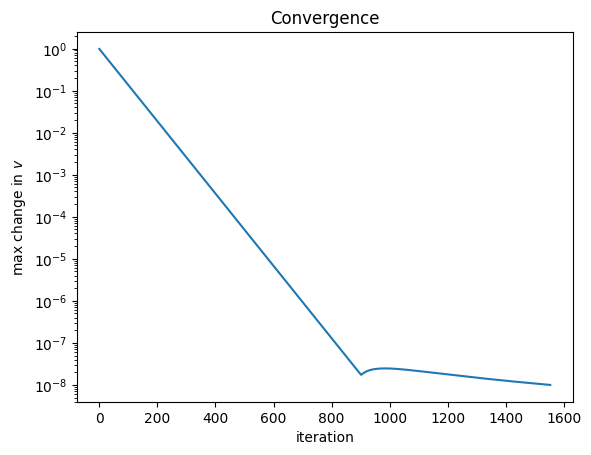

In [16]:
plt.plot(errors)
plt.yscale('log')
plt.title('Convergence')
plt.xlabel('iteration')
plt.ylabel('max change in $v$')
plt.savefig('figs/pih_vfi_ss_convergence.pdf')
plt.show()

The error falls at a constant rate on a log scale: each backward step shrinks the distance to the fixed point by roughly a factor $\beta$, exactly what the contraction mapping theorem promises.
With $\beta \approx 0.98$ that factor is close to one, which is why it takes about 1,500 iterations.
Each step is cheap thanks to `numba`, so we do not care here, but remember this: *the closer $\beta$ is to one, the slower value function iteration converges*.

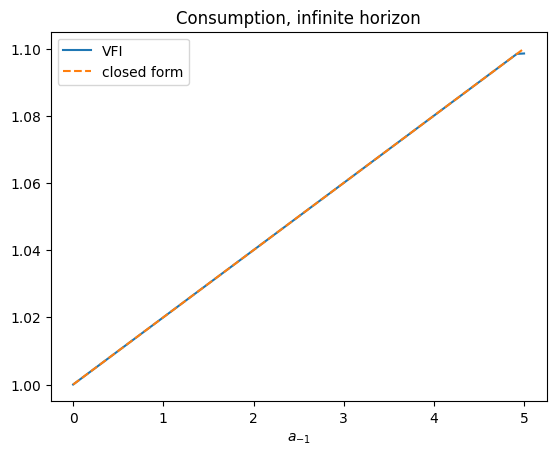

maximum relative error: 1.34e-03
MPC out of a windfall:  0.0195
PIH benchmark, r/(1+r): 0.0196


In [17]:
c_closed_ss = par.r*par.a_grid + y_ss

plt.plot(par.a_grid,c_ss,label='VFI')
plt.plot(par.a_grid,c_closed_ss,linestyle='--',label='closed form')
plt.title('Consumption, infinite horizon')
plt.xlabel('$a_{-1}$')
plt.legend()
plt.show()

MPC_ss = np.mean(np.diff(c_ss)/((1+par.r)*np.diff(par.a_grid)))

print(f'maximum relative error: {np.max(np.abs(c_ss/c_closed_ss-1)):.2e}')
print(f'MPC out of a windfall:  {MPC_ss:.4f}')
print(f'PIH benchmark, r/(1+r): {par.r/(1+par.r):.4f}')

The MPC is $\frac{r}{1+r} \approx 2\%$ and the *same at every wealth level*: the consumption function is a straight line.
This is the permanent income hypothesis in one picture, and it is what the data reject.

## Simulating a household

The policy functions tell us what a household *would* do in any state.
A *simulation* follows one household over time: run the budget constraint forward, reading consumption off the policy function each period.
Go back to the finite-horizon household of part 1, and start it with zero wealth.

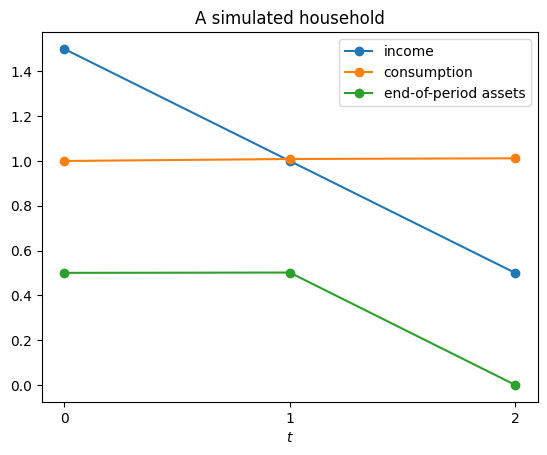

In [18]:
a_lag = 0.0
c_sim = np.zeros(par.T)
a_sim = np.zeros(par.T)

for t in range(par.T):
    c_sim[t] = interp_1d(par.a_grid,c[t],a_lag)
    a_sim[t] = (1+par.r)*a_lag + par.y[t] - c_sim[t]
    a_lag = a_sim[t]

plt.plot(par.y,'-o',label='income')
plt.plot(c_sim,'-o',label='consumption')
plt.plot(a_sim,'-o',label='end-of-period assets')
plt.xticks(range(par.T))
plt.title('A simulated household')
plt.xlabel('$t$')
plt.legend()
plt.savefig('figs/pih_simulation.pdf')
plt.show()

Income falls by two thirds over the life-cycle while consumption barely moves: the household saves while income is high and runs the savings down when it is low.
This is *consumption smoothing*, the heart of the permanent income hypothesis.
Note that there is no randomness anywhere: with a known income path, simulating is just running the budget constraint forward.
The next notebook adds income risk and a borrowing constraint, the closed form disappears, and the same forward loop becomes a Monte Carlo simulation.